# Benchmarking CNN Architectures for UC Severity Grading

This notebook trains and compares four CNN architectures (ResNet34, MobileNetV2, DenseNet121, EfficientNet-B0) on classifying endoscopy images by Mayo Endoscopic Score (0–3), a standard measure of ulcerative colitis severity. It builds one shared, patient-stratified dataset split, trains every architecture with the same two-phase fine-tuning protocol, and reports validation/test accuracy, F1, and Quadratic Weighted Kappa (QWK) so the architectures can be compared fairly.

**What it does:** Installs/upgrades the `fastai` deep learning library and `torchinfo` (a helper for inspecting model architectures) in this Colab session.

**Why it's needed:** Colab comes with some ML packages preinstalled, but not always the exact versions this notebook needs. `fastcore<2` is pinned deliberately — a newer fastcore release removed an API this version of fastai still relies on internally, so an unpinned upgrade can silently break training.

**What to expect:** Standard pip install log output — safe to ignore, no results here. If you ever change this cell, do **Runtime → Restart session** afterward; Python won't reload packages already imported in memory.

In [1]:
## for CLOAB
!pip install -U fastai "fastcore<2" torchinfo grad-cam statsmodels -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 102.4 MB/s eta 0:00:0000:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.1/108.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.4/80.4 kB 9.3 MB/s eta 0:00:00


**What it does:** Mounts your Google Drive into the Colab virtual machine's filesystem, at `/content/drive`.

**Why it's needed:** The endoscopy image dataset lives in your Drive (`Masters/Datasets/...`), not on the temporary Colab VM — mounting Drive lets this notebook read those files as if they were local.

**What to expect:** A one-time prompt to authorize Drive access, then a confirmation like "Mounted at /content/drive". If Drive was already mounted earlier in this session, you'll see a message saying so instead — that's fine.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**What it does:** Imports `Path` (for building filesystem paths) and `pandas` (for the tables of image paths/labels used throughout the notebook).

**Why it's needed:** Every later cell that touches file paths or builds a DataFrame depends on these two being available first.

**What to expect:** No output — this cell just makes tools available for later cells.

In [3]:
from pathlib import Path
import pandas as pd

**What it does:** Points at the two dataset folders on Drive (train+validation images, and held-out test images) and walks through them to build a table of every image's file path, its Mayo severity label, and which patient it belongs to.

**Why it's needed:** Everything downstream — the train/validation split, the DataLoaders, training — works off these `trainval_df`/`test_df` tables rather than touching the filesystem directly, so this cell is the single place that turns "folders of image files" into structured data.

**What to expect:** A styled "Dataset Summary" table — one row per Mayo/MES grade (0–3) plus a bold Total row, with Train+Val, Test, and combined Total counts. You should see roughly 9,590 train+val images and 1,686 test images (11,276 total) if the Drive folders are set up correctly — a big deviation from that usually means a wrong path.

**Why results are saved to Google Drive, not the Colab VM:** The Colab virtual machine's filesystem (anything under `/content/...` that isn't your mounted Drive) is ephemeral — it's wiped whenever the runtime disconnects or resets, along with anything saved there.

**What `RESULTS_DIR` does instead:** It points at a folder inside your mounted Google Drive (`/content/drive/MyDrive/Masters/results`), so anything saved there persists across sessions and — if you use Google Drive for Desktop — syncs back down to your PC automatically.

**What lands here:** Every figure and CSV this notebook produces — Grad-CAM images, the McNemar pairwise comparison table, and the final results table — is saved under `RESULTS_DIR`.

In [ ]:
TRAINING_VALIDATION_ROOT = Path("/content/drive/MyDrive/Masters/Datasets/train_and_validation_sets")
TEST_ROOT = Path("/content/drive/MyDrive/Masters/Datasets/test_set")

RESULTS_DIR = Path("/content/drive/MyDrive/Masters/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def build_df(root):
    records = []
    for mayo_dir in sorted(root.iterdir()):
        if not mayo_dir.is_dir():
            continue
        label = mayo_dir.name
        for img_path in mayo_dir.glob("*.bmp"):
            patient_id = img_path.stem.split("_")[2]
            records.append({"path": str(img_path), "label": label, "patient_id": patient_id})
    return pd.DataFrame(records)

trainval_df = build_df(TRAINING_VALIDATION_ROOT)
test_df = build_df(TEST_ROOT)

from IPython.display import display

mes_labels = {
    "Mayo 0": "MES 0 (normal)",
    "Mayo 1": "MES 1 (mild)",
    "Mayo 2": "MES 2 (moderate)",
    "Mayo 3": "MES 3 (severe)",
}

trainval_counts = trainval_df["label"].value_counts()
test_counts = test_df["label"].value_counts()

summary_df = pd.DataFrame({
    "MES Grade": list(mes_labels.values()),
    "Train + Val": [int(trainval_counts.get(k, 0)) for k in mes_labels],
    "Test": [int(test_counts.get(k, 0)) for k in mes_labels],
})
summary_df["Total"] = summary_df["Train + Val"] + summary_df["Test"]

total_row = pd.DataFrame([{
    "MES Grade": "Total",
    "Train + Val": int(summary_df["Train + Val"].sum()),
    "Test": int(summary_df["Test"].sum()),
    "Total": int(summary_df["Total"].sum()),
}])
summary_df = pd.concat([summary_df, total_row], ignore_index=True)

display(
    summary_df.style
    .hide(axis="index")
    .format({"Train + Val": "{:,}", "Test": "{:,}", "Total": "{:,}"})
    .set_caption("Dataset Summary")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"),
                                           ("text-align", "left"), ("padding-bottom", "6px")]},
        {"selector": "th", "props": [("text-align", "left"), ("padding", "4px 16px")]},
        {"selector": "td", "props": [("text-align", "left"), ("padding", "4px 16px")]},
    ])
    .set_properties(subset=pd.IndexSlice[[len(summary_df) - 1], :], **{"font-weight": "bold"})
)

**What it shows:** A quick peek at the `trainval_df` table — `.head()` previews the first few rows (path, label, patient_id), and `.info()` shows column dtypes, non-null counts, and memory usage.

**Why it's useful:** This is a fast sanity check that `build_df` built the table correctly — right columns, no unexpected missing values, sensible dtypes — before relying on it for the rest of the pipeline.

In [5]:
trainval_df.head()
trainval_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9590 entries, 0 to 9589
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   path        9590 non-null   object
 1   label       9590 non-null   object
 2   patient_id  9590 non-null   object
dtypes: object(3)
memory usage: 224.9+ KB


**What it does:** Imports everything needed for training (PyTorch, scikit-learn, the torchvision model architectures, and fastai's vision tools), then defines a single switch: `DEV_MODE`.

**Why it's needed:** `DEV_MODE` is the "fast test" toggle for the whole notebook. When `True`, later cells automatically shrink the dataset and training time so you can check the pipeline runs without errors in a couple of minutes instead of hours. When you're ready for a real benchmarking run, flip this one flag to `False` and every downstream cell (data size, epoch counts, number of architectures trained) adjusts automatically.

**Important:** Never trust results produced while `DEV_MODE=True` as real model performance — they're only a "did it run without crashing?" check, using a tiny, non-representative slice of data and a single epoch. Only a `DEV_MODE=False` run produces numbers worth reporting.

**What to expect:** No output — this cell just sets up imports and the flag.

In [6]:
import gc

import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as sklearn_f1, cohen_kappa_score
from torchvision.models import mobilenet_v2, densenet121, efficientnet_b0
from fastai.vision.all import (
    ImageDataLoaders, Resize, aug_transforms, Normalize, imagenet_stats,
    vision_learner, resnet34, valley, accuracy, F1Score, Metric,
)

# Flip to False once the pipeline below runs cleanly end-to-end.
# True  -> tiny data subset, 1 epoch per phase, only the first architecture
# False -> full dataset, full epoch counts, all architectures
DEV_MODE = True

**What it does:** Sets a fixed random seed (42) for Python's `random`, NumPy, and PyTorch (including GPU randomness).

**Why it's needed:** Deep learning involves a lot of randomness — data shuffling, weight initialisation, augmentation. Fixing the seed means re-running the notebook gives (near-)identical results each time, which makes debugging and comparing architectures fair, since differences you see between models come from the architecture, not random chance.

**What to expect:** No output.

In [7]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

**What it does:** Defines a helper that randomly samples a fixed number of images per Mayo class, then — only when `DEV_MODE` is on — shrinks both `trainval_df` and `test_df` down to a small, class-balanced subset (e.g. 40 images per class instead of thousands).

**Why it's needed:** Training on the full dataset takes a long time; this lets you sanity-check that the whole pipeline (data loading, training loop, evaluation) runs end-to-end in minutes instead of hours, before committing to a real run.

**Why sample this way:** Sampling an equal number per class (rather than, say, taking the first N rows) keeps the tiny dev-mode dataset balanced across severity grades, so the class-weighting and metric cells still behave sensibly on the shrunk data.

**Important — dev-mode results are not real results:** This subsampling happens *before* the patient-stratified split in the next cell, so a dev-mode run can end up with the same patient's images split across train and validation. That's fine for a quick smoke test, but it means dev-mode accuracy/QWK numbers must never be treated as real model performance — only `DEV_MODE=False` results should be trusted or reported.

**What to expect:** A line like `[DEV_MODE] Subsetted to 160 train/val images, 160 test images` — only printed when `DEV_MODE=True`.

In [8]:
def stratified_subsample(df, n_per_class, seed=42):
    parts = [
        g.sample(n=min(n_per_class, len(g)), random_state=seed)
        for _, g in df.groupby("label")
    ]
    return pd.concat(parts).reset_index(drop=True)

# NOTE: subsampling happens before the patient split below, so DEV_MODE results
# may contain patient leakage (the same patient could end up in both train and
# val). DEV_MODE output is only to verify the pipeline runs end-to-end — never
# treat it as a real result.
if DEV_MODE:
    N_PER_CLASS = 40
    trainval_df = stratified_subsample(trainval_df, N_PER_CLASS)
    test_df = stratified_subsample(test_df, N_PER_CLASS)
    print(f"[DEV_MODE] Subsetted to {len(trainval_df)} train/val images, {len(test_df)} test images")

[DEV_MODE] Subsetted to 160 train/val images, 160 test images


**What it does:** Splits patients (not individual images) into a training group and a validation group, keeping the same proportion of each Mayo grade in both groups.

**Why it's needed:** This prevents **data leakage**. Each patient contributes many image frames, and frames from the same patient tend to look similar (same mucosa, same lighting, same endoscope). If some of a patient's frames ended up in training and others in validation, the model could partly "recognise the patient" rather than learn the actual severity grade, making validation performance look better than the model really is. Splitting by patient ID guarantees no patient's images appear in both sets, so validation performance reflects how well the model generalises to genuinely new patients — which is what actually matters clinically.

**What to expect:** Counts of how many patients and how many images ended up in training vs. validation.

In [9]:
patient_dominant_label = (
    trainval_df.groupby("patient_id")["label"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={"label": "dominant_label"})
)

patients = patient_dominant_label["patient_id"].values
strata_labels = patient_dominant_label["dominant_label"].values

train_patients, val_patients = train_test_split(
    patients,
    test_size=0.20,
    random_state=42,   # fixed — keep identical across all architectures
    stratify=strata_labels,
)

val_patients_set = set(val_patients)
trainval_df["is_valid"] = trainval_df["patient_id"].apply(lambda p: p in val_patients_set)

print(f"Training patients: {len(train_patients)}")
print(f"Validation patients: {len(val_patients)}")
print(f"Training images: {trainval_df['is_valid'].eq(False).sum()}")
print(f"Validation images: {trainval_df['is_valid'].eq(True).sum()}")

Training patients: 92
Validation patients: 24
Training images: 126
Validation images: 34


**What it shows:** The Mayo-grade class distribution separately for the training split and the validation split, plus a hard assertion that no patient ID appears in both.

**Why it's useful:** This directly verifies the patient-stratified split worked as intended — both splits should show a similar proportional class mix — and turns "no leakage" from a claim into something the notebook actually checks, failing loudly if it's ever broken.

In [10]:
train_split_df = trainval_df[~trainval_df["is_valid"]]
val_split_df = trainval_df[trainval_df["is_valid"]]

print("Train split class distribution:")
print(train_split_df["label"].value_counts().sort_index())
print("\nValidation split class distribution:")
print(val_split_df["label"].value_counts().sort_index())

train_patients_check = set(train_split_df["patient_id"])
val_patients_check = set(val_split_df["patient_id"])
assert train_patients_check.isdisjoint(val_patients_check), "Patient leakage detected between train and validation splits!"
print("\nNo patient overlap between train and validation splits.")

Train split class distribution:
label
Mayo 0    31
Mayo 1    32
Mayo 2    31
Mayo 3    32
Name: count, dtype: int64

Validation split class distribution:
label
Mayo 0    9
Mayo 1    8
Mayo 2    9
Mayo 3    8
Name: count, dtype: int64

No patient overlap between train and validation splits.


**What it does:** Builds fastai's `DataLoaders` object — the thing that actually feeds batches of images and labels into the model during training. It resizes every image to 224×224, applies random augmentations (rotation, zoom, lighting changes), and normalises pixel values.

**Why it's needed:** All four architectures need to see data prepared in exactly the same way, so any performance difference between them comes from the architecture itself, not from one getting easier data.

**What the augmentations do:** Small random rotations, zooms, and lighting shifts show the model slightly varied versions of each image every epoch, which reduces overfitting on a relatively small medical dataset. Vertical flipping is deliberately turned off, since endoscopy images have a fixed real-world orientation — flipping them would create unrealistic images.

**Why `imagenet_stats`:** These architectures start from ImageNet-pretrained weights, which expect input pixels normalised using ImageNet's mean/std statistics. Matching that same normalisation here is what makes transfer learning from those pretrained weights actually work well.

**What to expect:** The class vocabulary (the four Mayo labels) and the number of images in the training and validation sets.

In [11]:
IMG_SIZE = 224
BATCH_SIZE = 32

dls = ImageDataLoaders.from_df(
    trainval_df,
    # fn_col already holds absolute paths — fastai always prepends "path/" to
    # fn_col, so path="." would join into the broken "./" + "/content/...".
    # path="/" collapses back into a valid absolute path instead.
    path="/",
    fn_col="path",
    label_col="label",
    is_valid_col="is_valid",
    item_tfms=Resize(IMG_SIZE),
    batch_tfms=[
        *aug_transforms(
            flip_vert=False,
            max_rotate=15,
            max_zoom=1.1,
            max_lighting=0.2,
            p_lighting=0.75,
        ),
        Normalize.from_stats(*imagenet_stats),
    ],
    bs=BATCH_SIZE,
    num_workers=2,
)
dls.path = TRAINING_VALIDATION_ROOT.parent   # keep any future checkpoints under Datasets/, not "/"

print("Class vocabulary:", dls.vocab)
print("Training set size:", len(dls.train_ds))
print("Validation set size:", len(dls.valid_ds))

Class vocabulary: ['Mayo 0', 'Mayo 1', 'Mayo 2', 'Mayo 3']
Training set size: 128
Validation set size: 32


**What it shows:** A sample batch of training images exactly as the model will see them — after resizing, random augmentation (rotation/zoom/lighting), and normalisation.

**Why it's useful:** This is the best way to catch data problems early — wrong labels, broken images, or augmentation settings that are too aggressive or too weak — before spending time training a model on it.

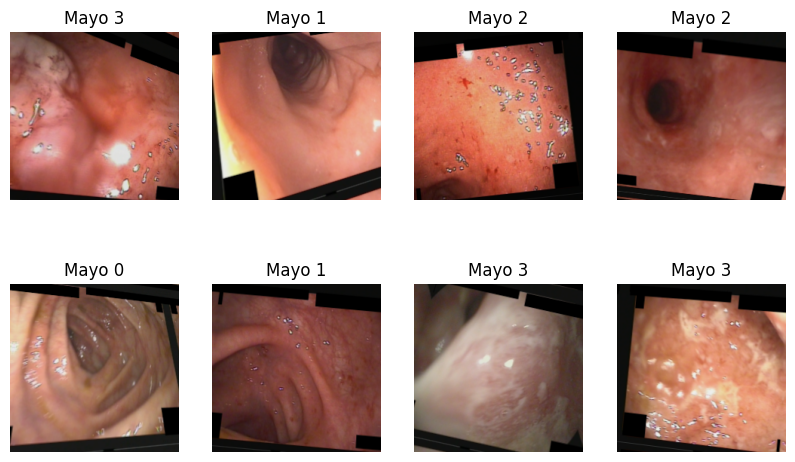

In [12]:
dls.show_batch(max_n=8, figsize=(10, 6))

**What it does:** Computes a per-class weight (Mayo 0 is roughly half the dataset, Mayo 3 the rarest) and builds a weighted cross-entropy loss function using those weights, on whichever device is fastest available (MPS, then CUDA, then CPU).

**Why it's needed:** Without weighting, a model can get deceptively good-looking accuracy just by mostly predicting the majority class (Mayo 0) and largely ignoring the rare classes. Weighting the loss makes mistakes on rare classes count for more during training, pushing the model to actually learn to distinguish all four grades.

**How the formula normalises the weights:** `weight = total_images / (num_classes * class_count)` gives each class a weight inversely proportional to how common it is — rarer classes get bigger weights. The result is then rescaled (divided by the weights' sum, multiplied by the number of classes) so the weights average out to 1 across classes. This keeps the loss's overall scale comparable to an unweighted loss — it only redistributes emphasis between classes rather than inflating the loss magnitude overall.

**What to expect:** Which device training will run on, then each class's count and computed weight. In dev mode, all four should show `weight=1.0000` since dev-mode subsampling makes the classes perfectly balanced.

In [13]:
vocab = dls.vocab
class_counts = trainval_df["label"].value_counts()
counts_ordered = np.array([class_counts.get(v, 0) for v in vocab], dtype=np.float32)
N_total = counts_ordered.sum()
C = len(vocab)
weights = N_total / (C * counts_ordered)
weights = weights / weights.sum() * C

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Running on: {device}")
for cls, n, w in zip(vocab, counts_ordered.astype(int), weights):
    print(f"  {cls}: count={n:>5d}  weight={w:.4f}")

weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
weighted_ce_loss = nn.CrossEntropyLoss(weight=weights_tensor, reduction="mean")

Running on: cuda
  Mayo 0: count=   40  weight=1.0000
  Mayo 1: count=   40  weight=1.0000
  Mayo 2: count=   40  weight=1.0000
  Mayo 3: count=   40  weight=1.0000


**What it shows:** Two bar charts side by side — raw image counts per Mayo class, and the normalised loss weights computed for each class.

**Why it's useful:** Seeing both charts together makes the class imbalance and its correction visually obvious — the rarest class (shortest bar on the left) should line up with the tallest bar on the right, confirming the weighting is doing what it's supposed to.

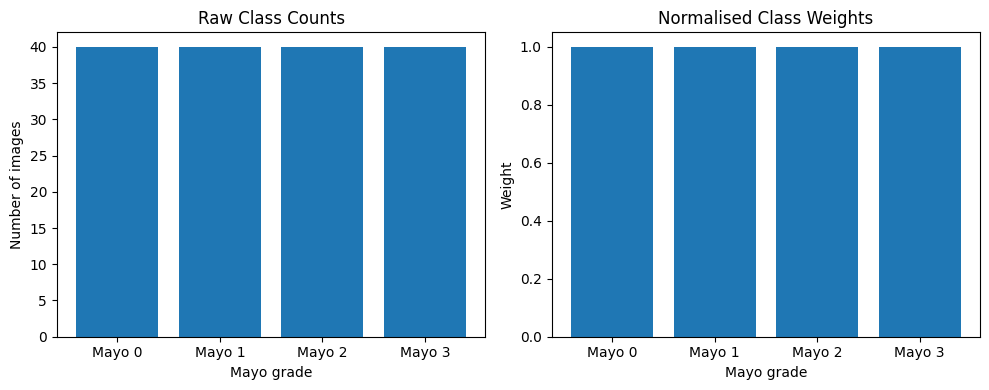

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(vocab, counts_ordered)
axes[0].set_title("Raw Class Counts")
axes[0].set_xlabel("Mayo grade")
axes[0].set_ylabel("Number of images")

axes[1].bar(vocab, weights)
axes[1].set_title("Normalised Class Weights")
axes[1].set_xlabel("Mayo grade")
axes[1].set_ylabel("Weight")

plt.tight_layout()
plt.show()

**What it does:** Defines a custom metric class that fastai tracks during training, implementing Quadratic Weighted Kappa (QWK).

**Why it's needed:** Mayo grades are *ordinal* — 0, 1, 2, 3 represent increasing severity, not unrelated categories. Plain accuracy treats every mistake the same: confusing Mayo 0 with Mayo 1 counts exactly the same as confusing Mayo 0 with Mayo 3, even though the second error is far more clinically serious.

**What QWK measures:** It penalises predictions in proportion to how far off they are on the severity scale (a 2-grade miss costs more than a 1-grade miss), and it also corrects for the agreement you'd expect from pure chance. That combination is why it's the standard, more clinically meaningful metric for ordinal grading tasks like this one, instead of plain accuracy.

**What to expect:** No output directly from this cell — it just defines the metric class, which shows up as a "qwk" column once training starts.

In [15]:
class QuadraticWeightedKappa(Metric):
    """fastai-compatible metric: reset() -> accumulate() per batch -> .value per epoch."""

    def __init__(self):
        self.preds = []
        self.targs = []

    def reset(self):
        self.preds = []
        self.targs = []

    def accumulate(self, learn):
        self.preds.extend(learn.pred.argmax(dim=1).cpu().numpy().tolist())
        self.targs.extend(learn.yb[0].cpu().numpy().tolist())

    @property
    def value(self):
        if not self.preds:
            return None
        return cohen_kappa_score(self.targs, self.preds, weights="quadratic")

    @property
    def name(self):
        return "qwk"

    def __repr__(self):
        return "QuadraticWeightedKappa()"

**What it does:** Lists the four architectures to benchmark (ResNet34, MobileNetV2, DenseNet121, EfficientNet-B0) and sets how many training epochs each phase gets — automatically cut down to 1 architecture and 1 epoch per phase when `DEV_MODE` is on.

**Why it's needed:** This is the single place that controls which models get trained and for how long, so the benchmarking loop later doesn't need to change to add/remove architectures or adjust epoch counts.

**What to expect:** A summary line showing the current `DEV_MODE` state, which architectures will be trained, and the epoch counts for each phase.

In [ ]:
ARCHITECTURES = {
    "ResNet34": resnet34,
    "MobileNetV2": mobilenet_v2,
    "DenseNet121": densenet121,
    "EfficientNet-B0": efficientnet_b0,
}

# vision_learner needs to know where to split a model into backbone/head. it tries to auto-detect this
# by searching for a pooling layer, which fails for mobilenet_v2 (its pooling is done inline inside
# forward(), not as a registered layer) -> raises StopIteration. passing cut= directly to vision_learner
# does NOT fix this - verified that fastai 2.8.7's vision_learner silently drops its own cut= argument,
# never forwarding it to the underlying model builder. the fix that actually works: register the cut
# point in fastai's own model_meta lookup table, which the model builder DOES correctly check.
from fastai.vision.learner import model_meta, _default_meta
model_meta[mobilenet_v2] = {**_default_meta, "cut": -1}   # -1 = use mobilenet_v2.features as the backbone

if DEV_MODE:
    ARCHITECTURES = dict(list(ARCHITECTURES.items())[:1])   # first model only
    EPOCHS_HEAD = 1
    EPOCHS_FULL = 1
else:
    EPOCHS_HEAD = 5
    EPOCHS_FULL = 15

print(f"DEV_MODE={DEV_MODE}  ->  architectures: {list(ARCHITECTURES)}  epochs: {EPOCHS_HEAD}+{EPOCHS_FULL}")

**What it does:** Measures how long a single forward pass takes — on CPU, and on GPU (CUDA if available, otherwise MPS) — for an already-trained model.

**Why latency matters clinically:** A model reviewing archived images offline can take as long as it needs. A model assisting live during an endoscopy procedure needs to return a grade in real time, while the endoscopist is still looking at that frame — so inference speed is itself a clinical requirement, not just an engineering detail.

**Why batch size 1:** During a live procedure, frames arrive one at a time, not in convenient batches — timing batch size 1 reflects that real deployment scenario, not the throughput-optimised batches used during training.

**Why warmup iterations:** The first call into a GPU model triggers one-time costs — kernel compilation, memory allocation — that have nothing to do with the model's steady-state speed. Running 10 untimed warmup passes lets those one-time costs happen before the clock starts.

**Why mean ± std, not a single measurement:** Any single timing is noisy (background system activity, scheduling jitter). Averaging over 100 repeats gives a stable mean, and the standard deviation alongside it shows how consistent that latency actually is.

In [17]:
import time

def benchmark_latency(learn, dls, n_warmup=10, n_repeats=100):
    model = learn.model
    model.eval()
    original_device = next(model.parameters()).device

    xb, _ = dls.valid.one_batch()
    xb = xb[:1]   # batch size 1 — real-time clinical scenario, one image at a time

    def _time_on(device):
        model.to(device)
        x = xb.to(device)
        is_cuda = device.type == "cuda"
        is_mps = device.type == "mps"

        with torch.no_grad():
            for _ in range(n_warmup):
                _ = model(x)
            if is_cuda:
                torch.cuda.synchronize()
            elif is_mps:
                torch.mps.synchronize()

            times_ms = []
            for _ in range(n_repeats):
                if is_cuda:
                    torch.cuda.synchronize()
                elif is_mps:
                    torch.mps.synchronize()
                t0 = time.perf_counter()
                _ = model(x)
                if is_cuda:
                    torch.cuda.synchronize()
                elif is_mps:
                    torch.mps.synchronize()
                times_ms.append((time.perf_counter() - t0) * 1000)

        return float(np.mean(times_ms)), float(np.std(times_ms))

    cpu_ms_mean, cpu_ms_std = _time_on(torch.device("cpu"))

    if torch.cuda.is_available():
        gpu_device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        gpu_device = torch.device("mps")
    else:
        gpu_device = None

    if gpu_device is not None:
        gpu_ms_mean, gpu_ms_std = _time_on(gpu_device)
    else:
        gpu_ms_mean, gpu_ms_std = None, None

    model.to(original_device)

    gpu_str = f"{gpu_ms_mean:.2f} ± {gpu_ms_std:.2f} ms/image" if gpu_ms_mean is not None else "N/A (no CUDA/MPS available)"
    print(f"LATENCY -> CPU: {cpu_ms_mean:.2f} ± {cpu_ms_std:.2f} ms/image, GPU: {gpu_str}")

    return {
        "cpu_ms_mean": round(cpu_ms_mean, 4),
        "cpu_ms_std": round(cpu_ms_std, 4),
        "gpu_ms_mean": round(gpu_ms_mean, 4) if gpu_ms_mean is not None else None,
        "gpu_ms_std": round(gpu_ms_std, 4) if gpu_ms_std is not None else None,
    }

**What it does:** Grad-CAM highlights which pixels most influenced the model's predicted Mayo grade, by tracing the gradient of that prediction back into the last convolutional layer's feature maps and turning that into a heatmap over the original image.

**Why it matters for clinical trust:** A model can reach the right answer for the wrong reason — e.g. picking up on image compression artefacts, glare, or endoscope hardware visible in the frame rather than the mucosa itself. Grad-CAM makes that visible: a clinician can look at the heatmap and judge whether the model is actually looking at the tissue that matters, not just trust a number.

**How the heatmap is computed:** We run a forward pass, then backpropagate from the predicted class's score into the last convolutional layer (rather than all the way to the input pixels). Each feature map in that layer gets a weight equal to its average gradient, and the weighted sum of feature maps (after a ReLU, which keeps only the influence that pushed *toward* that class) becomes the heatmap — a coarse map of "where in the image support for this prediction came from." We use the [pytorch-grad-cam](https://github.com/jacobgil/pytorch-grad-cam) library (Gildenblat, 2021) to implement this — a standard, well-cited XAI library for CNN interpretability, implementing the Grad-CAM method from Selvaraju et al. (2017), rather than hand-rolling the hook/backward logic ourselves.

**Why one image per MES class:** Ulcerative colitis severity spans a spectrum — the visual features that matter (vascular pattern visibility, bleeding, ulceration depth) change from Mayo 0 to Mayo 3. Checking one example per grade is a quick way to see whether the model attends to clinically relevant regions consistently across the whole severity range, not just for one easy class.

**What a "good" heatmap looks like:** Concentrated on mucosal features — vascular patterns, areas of bleeding or ulceration, tissue texture — rather than on image borders, specular glare, or visible endoscope equipment. A heatmap that lights up the image edges or a glare spot instead of the tissue is a warning sign the model may be relying on spurious correlations rather than the actual pathology.

In [18]:
from pathlib import Path
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def compute_gradcam(learn, image_tensor, target_class_idx):
    model = learn.model
    model.eval()
    device = next(model.parameters()).device

    x = image_tensor.unsqueeze(0) if image_tensor.dim() == 3 else image_tensor
    x = x.to(device)

    backbone = model[0]
    target_layer = None
    for module in backbone.modules():
        if isinstance(module, nn.Conv2d):
            target_layer = module   # keep overwriting -> ends on the last Conv2d

    if target_layer is None:
        raise RuntimeError("No Conv2d layer found in backbone")

    targets = [ClassifierOutputTarget(target_class_idx)]
    with GradCAM(model=model, target_layers=[target_layer]) as cam:
        heatmap = cam(input_tensor=x, targets=targets)   # (1, 224, 224), normalised to [0, 1]

    return heatmap[0]


def visualize_interpretability(learn, dls, test_df, arch_name):
    slug = arch_name.replace(" ", "_").replace("-", "_").lower()
    out_dir = RESULTS_DIR / slug
    out_dir.mkdir(parents=True, exist_ok=True)

    device = next(learn.model.parameters()).device
    vocab = list(dls.vocab)
    selected = []

    for class_idx, class_name in enumerate(vocab):
        class_df = test_df[test_df["label"] == class_name]

        chosen_path = None
        chosen_pred_idx = None
        chosen_xb = None

        for img_path in class_df["path"]:
            xb = dls.test_dl([img_path], num_workers=0).one_batch()[0]
            with torch.no_grad():
                pred = learn.model(xb.to(device))
            pred_idx = int(pred.argmax(dim=1)[0])

            if pred_idx == class_idx:
                chosen_path, chosen_pred_idx, chosen_xb = img_path, pred_idx, xb
                break

        if chosen_path is None:
            chosen_path = class_df["path"].iloc[0]
            chosen_xb = dls.test_dl([chosen_path], num_workers=0).one_batch()[0]
            with torch.no_grad():
                pred = learn.model(chosen_xb.to(device))
            chosen_pred_idx = int(pred.argmax(dim=1)[0])

        cam = compute_gradcam(learn, chosen_xb[0], chosen_pred_idx)
        orig_img = np.array(Image.open(chosen_path).convert("RGB").resize((224, 224)))

        selected.append({
            "class_name": class_name,
            "path": chosen_path,
            "pred_idx": chosen_pred_idx,
            "orig_img": orig_img,
            "cam": cam,
        })

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for col, item in enumerate(selected):
        pred_label = vocab[item["pred_idx"]]

        axes[0, col].imshow(item["orig_img"])
        axes[0, col].set_title(f"True: {item['class_name']}\nPred: {pred_label}", fontsize=10)
        axes[0, col].axis("off")

        orig_img_float = item["orig_img"].astype(np.float32) / 255.0
        overlay = show_cam_on_image(orig_img_float, item["cam"], use_rgb=True, image_weight=0.55)
        axes[1, col].imshow(overlay)
        axes[1, col].set_title("Grad-CAM", fontsize=10)
        axes[1, col].axis("off")

    plt.tight_layout()
    save_path = out_dir / "gradcam.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Grad-CAM figure saved -> {save_path}")

    return [(item["path"], item["pred_idx"]) for item in selected]

**What it does:** Defines the function that runs the full training procedure for one architecture: build the model, train just the new classification head first, then unfreeze and fine-tune the whole network.

**Why it's needed:** This encapsulates the entire training recipe so the benchmarking loop can call it identically for every architecture — same protocol, so any performance difference reflects the architecture, not the training procedure.

**Why two phases (frozen head, then unfreeze):** Each architecture starts with ImageNet-pretrained weights, but its final classification layer is brand new and randomly initialised (ImageNet doesn't have "Mayo 0–3" classes). Phase 1 freezes the pretrained backbone and only trains that new head — this lets the head learn something sensible quickly without messy random gradients disturbing the good pretrained features. Phase 2 unfreezes everything and fine-tunes the whole network at a lower learning rate, letting the pretrained layers adapt to the specifics of endoscopy images.

**Why `lr_find`:** Picking a learning rate by hand is guesswork — too high and training diverges, too low and it barely learns anything in the epoch budget. `lr_find` runs a quick mock-training pass across a range of learning rates and finds the "valley" — where loss is still dropping steeply but hasn't gone unstable — and that becomes the actual training rate for that phase.

**What to expect:** Progress bars per epoch, the learning rate found for each phase, and a final summary line with validation accuracy, F1, and QWK for that architecture.

In [ ]:
def train_architecture(arch_name, arch_fn, dls, loss_func):
    print(f"\n{'=' * 60}\n  Architecture: {arch_name}\n{'=' * 60}")

    qwk = QuadraticWeightedKappa()
    f1 = F1Score(average="macro")
    mets = [accuracy, f1, qwk]

    # (mobilenet_v2's backbone/head split is handled globally via model_meta in the ARCHITECTURES cell,
    # not here - passing cut= directly to vision_learner doesn't work, see that cell's comment)
    learn = vision_learner(dls, arch_fn, loss_func=loss_func, metrics=mets)

    print("\n-- Phase 1: frozen backbone --")
    lr_head = learn.lr_find(suggest_funcs=(valley,), show_plot=False).valley
    print(f"  LR (valley): {lr_head:.2e}")
    learn.fit_one_cycle(EPOCHS_HEAD, lr_head)

    print("\n-- Phase 2: full fine-tune --")
    learn.unfreeze()
    lr_full = learn.lr_find(suggest_funcs=(valley,), show_plot=False).valley
    print(f"  LR (valley): {lr_full:.2e}")
    learn.fit_one_cycle(EPOCHS_FULL, slice(lr_full / 10, lr_full))

    final = learn.recorder.values[-1]
    metrics = {
        "train_loss": float(final[0]),
        "valid_loss": float(final[1]),
        "val_acc": float(final[2]),
        "val_f1": float(final[3]),
        "val_qwk": float(final[4]),
    }
    print(f"\n  Done -> val_acc={metrics['val_acc']:.4f}  "
          f"f1={metrics['val_f1']:.4f}  qwk={metrics['val_qwk']:.4f}")
    return learn, metrics

**What it does:** Defines two helpers: `evaluate_on_test` runs the trained model once against the held-out test set (data it never saw during training or validation) and computes accuracy/F1/QWK; `clear_memory` frees up GPU/MPS memory between architectures.

**Why it's needed:** Validation metrics can be slightly optimistic since they've indirectly influenced training decisions (like when to stop) — the test set gives an unbiased final read on how well the model generalises. `clear_memory` matters because loading four large CNNs back-to-back in one Colab session can otherwise exhaust available GPU memory.

**What to expect:** No output from defining these functions — the `TEST -> acc=... f1=... qwk=...` line appears later, once the benchmarking loop actually calls `evaluate_on_test`.

In [20]:
def evaluate_on_test(learn, test_df, dls):
    test_dl = dls.test_dl(test_df["path"].tolist(), num_workers=2)
    test_preds_raw, _ = learn.get_preds(dl=test_dl)

    label_to_idx = {v: i for i, v in enumerate(dls.vocab)}
    test_targets = torch.tensor([label_to_idx[l] for l in test_df["label"]])

    pred_cls = test_preds_raw.argmax(dim=1).numpy()
    true_cls = test_targets.numpy()

    test_acc = float((pred_cls == true_cls).mean())
    test_f1 = float(sklearn_f1(true_cls, pred_cls, average="macro"))
    test_qwk = float(cohen_kappa_score(true_cls, pred_cls, weights="quadratic"))

    print(f"  TEST -> acc={test_acc:.4f}  f1={test_f1:.4f}  qwk={test_qwk:.4f}")
    return {"test_acc": test_acc, "test_f1": test_f1, "test_qwk": test_qwk}, pred_cls, true_cls


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

**What it does:** Computes a 95% bootstrap confidence interval for accuracy, macro F1, and QWK on the test set.

**What a bootstrap CI is, and why point estimates aren't enough:** A single number like "test accuracy = 0.87" hides how much that number would wobble if you'd happened to test on a slightly different sample of images. For a thesis-quality comparison between architectures, a bare point estimate invites over-interpreting small differences that could just be sampling noise — a confidence interval quantifies that uncertainty directly.

**How the resampling works:** We don't have a second test set to re-measure on, so bootstrapping simulates that by resampling the *existing* test predictions with replacement (some images counted more than once, others left out) to build a new "pseudo test set" of the same size. We compute accuracy/F1/QWK on that resample, repeat this 1,000 times, and the spread of those 1,000 values becomes our uncertainty estimate.

**Why 95% CIs:** Reporting the 2.5th and 97.5th percentiles of the bootstrap distribution as a 95% interval is the standard convention in medical AI literature — it's the confidence level readers and reviewers expect, and it makes results directly comparable to other published work.

**Why this strengthens the results discussion:** If two architectures' 95% CIs for QWK overlap substantially, you can't confidently claim one architecture is actually better — the observed difference could be within the noise of this particular test set. Non-overlapping CIs are much stronger evidence of a real difference. (`stored_preds`, populated in the benchmarking loop below, keeps the raw predictions around for a McNemar's test — an even more direct statistical answer to "is this difference significant?" — if that's added later.)

In [21]:
def bootstrap_ci(true_cls, pred_cls, n_resamples=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(true_cls)

    acc_boot = []
    f1_boot = []
    qwk_boot = []

    for _ in range(n_resamples):
        idx = rng.integers(0, n, size=n)
        t = true_cls[idx]
        p = pred_cls[idx]

        acc_boot.append(float((p == t).mean()))
        f1_boot.append(float(sklearn_f1(t, p, average="macro")))
        try:
            qwk_boot.append(float(cohen_kappa_score(t, p, weights="quadratic")))
        except ValueError:
            pass   # a resample can occasionally contain too few distinct classes for QWK

    ci = {
        "acc_ci_low": float(np.percentile(acc_boot, 2.5)),
        "acc_ci_high": float(np.percentile(acc_boot, 97.5)),
        "f1_ci_low": float(np.percentile(f1_boot, 2.5)),
        "f1_ci_high": float(np.percentile(f1_boot, 97.5)),
        "qwk_ci_low": float(np.percentile(qwk_boot, 2.5)),
        "qwk_ci_high": float(np.percentile(qwk_boot, 97.5)),
    }

    print(f"BOOTSTRAP CI (95%) -> acc: [{ci['acc_ci_low']:.4f}, {ci['acc_ci_high']:.4f}], "
          f"f1: [{ci['f1_ci_low']:.4f}, {ci['f1_ci_high']:.4f}], "
          f"qwk: [{ci['qwk_ci_low']:.4f}, {ci['qwk_ci_high']:.4f}]")

    return ci

**What it does:** Runs McNemar's test between ResNet34 (the baseline) and each other trained architecture, using the paired predictions already stored in `stored_preds`.

**What McNemar's test measures:** Whether two models disagree with each other more often in one direction than the other — i.e. whether one model is significantly more likely to be right when the other is wrong, rather than the two making similar numbers of "wins" over each other purely by chance.

**Why it's the standard test for comparing classifiers here:** Both models were evaluated on the exact same test images, so their predictions are *paired* — each test image gives one outcome for model A and one for model B on the same underlying difficulty. McNemar's test is designed exactly for this paired setting (it only looks at the disagreements, not at cases where both models agree), unlike tests that assume independent samples.

**Why ResNet34 as the baseline:** It's the established, well-studied baseline architecture in the medical imaging literature — every other architecture's improvement (or regression) is measured relative to it, giving a single consistent reference point instead of comparing every pair of architectures to every other pair.

**How to interpret the p-value:** p < 0.05 means the difference in error patterns between ResNet34 and the other architecture is unlikely to be due to chance alone — a statistically significant difference. p ≥ 0.05 means we can't rule out that the observed difference is just noise from this particular test set.

In [22]:
from statsmodels.stats.contingency_tables import mcnemar

def run_mcnemar_test(preds_a, preds_b, name_a="A", name_b="B"):
    assert np.array_equal(preds_a["true"], preds_b["true"]), \
        "Both models must be evaluated on the same test set (true labels differ)"

    true = preds_a["true"]
    correct_a = preds_a["pred"] == true
    correct_b = preds_b["pred"] == true

    both_correct      = int((correct_a & correct_b).sum())
    a_correct_b_wrong = int((correct_a & ~correct_b).sum())
    a_wrong_b_correct = int((~correct_a & correct_b).sum())
    both_wrong        = int((~correct_a & ~correct_b).sum())

    table = [[both_correct, a_correct_b_wrong],
             [a_wrong_b_correct, both_wrong]]

    n_disagreements = a_correct_b_wrong + a_wrong_b_correct
    is_exact = n_disagreements < 25   # exact binomial for small samples, chi-squared otherwise

    result = mcnemar(table, exact=is_exact, correction=not is_exact)

    print(f"McNemar {name_a} vs {name_b}: p={result.pvalue:.4f} (n_disagreements={n_disagreements})")

    return {
        "statistic": float(result.statistic),
        "p_value": float(result.pvalue),
        "n_disagreements": n_disagreements,
    }

**What it does:** The main loop — for every architecture in `ARCHITECTURES`, trains it, evaluates it on the test set, records the results, then frees memory before moving to the next one. At the end, builds a results table sorted by test QWK (best model first).

**Why it's needed:** This is what actually runs everything defined above and produces the final comparison you care about — which architecture performs best on this task.

**What to expect:** For each architecture: training progress bars, then a `TEST -> ...` line. Once all architectures finish, a "FINAL RESULTS" table showing validation and test accuracy/F1/QWK for every architecture, sorted so the best-performing one (by QWK) is at the top.

**What it shows:** The loop below now also plots each architecture's training/validation loss curve right after it finishes training, before its `Learner` is deleted to free memory.

**Why it's useful:** A single final metric can't reveal training dynamics — the loss curves show whether validation loss started climbing again partway through (overfitting) or whether the model was still improving when training stopped.


  Architecture: ResNet34
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 236MB/s]



-- Phase 1: frozen backbone --


<div></div>

  LR (valley): 1.00e-03


...

<div></div>

  LR (valley): 1.10e-04


epoch,train_loss,valid_loss,accuracy,f1_score,qwk,time
0,2.084071,1.915148,0.312500,0.306653,-0.016688,00:00



  Done -> val_acc=0.3125  f1=0.3067  qwk=-0.0167


  TEST -> acc=0.3312  f1=0.3138  qwk=0.3186
BOOTSTRAP CI (95%) -> acc: [0.2625, 0.4002], f1: [0.2462, 0.3783], qwk: [0.1773, 0.4571]
LATENCY -> CPU: 34.12 ± 2.05 ms/image, GPU: 9.84 ± 0.26 ms/image


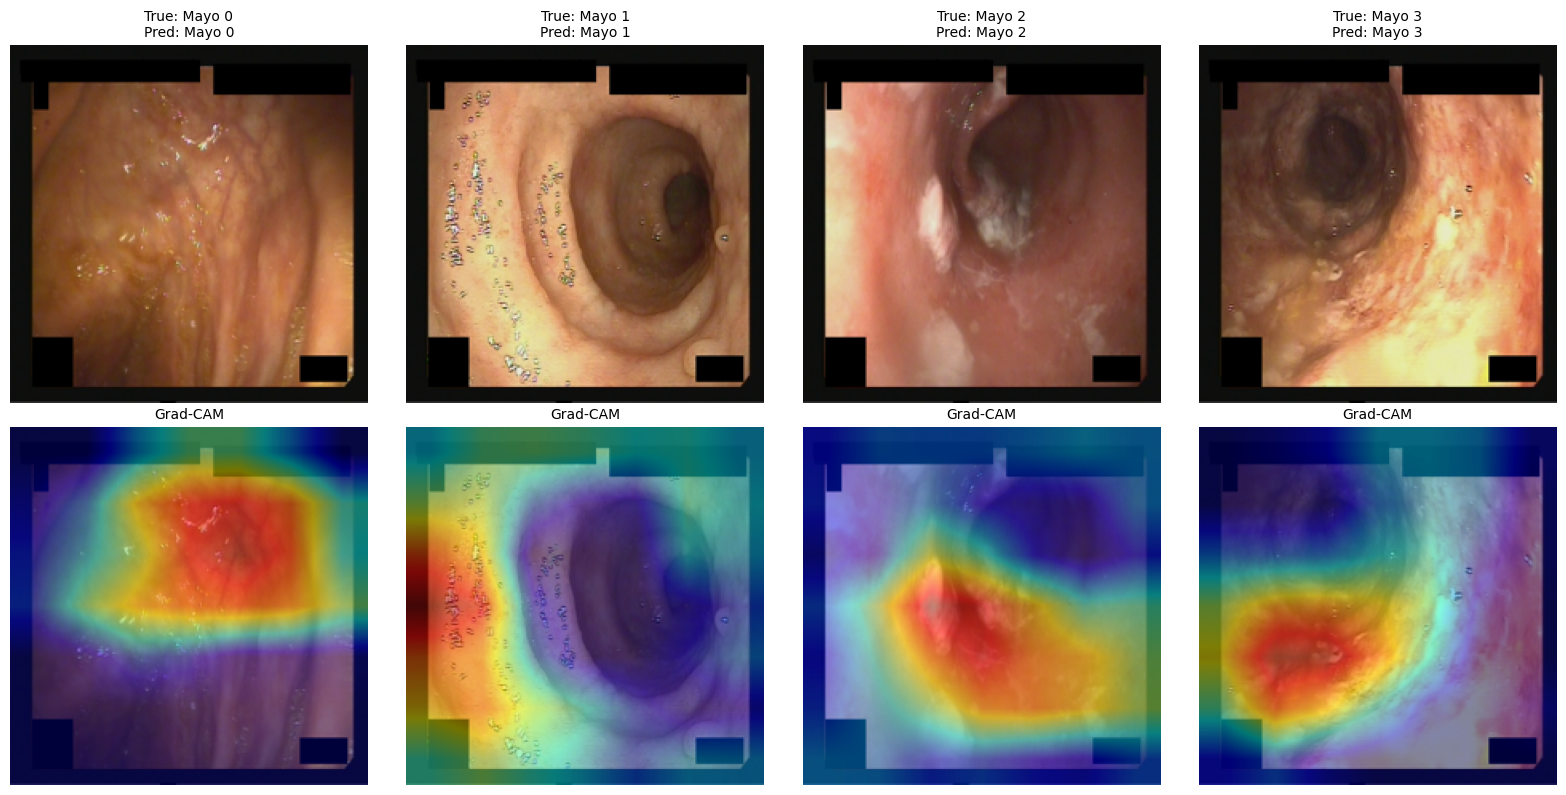

Grad-CAM figure saved -> /content/drive/MyDrive/Masters/results/resnet34/gradcam.png


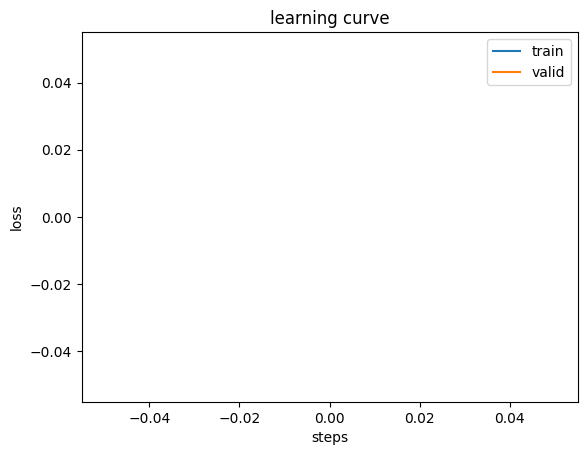

,Accuracy,Acc 95% CI,F1 (macro),F1 95% CI,QWK,QWK 95% CI
model,,,,,,
ResNet34,0.3312,"[0.2625, 0.4002]",0.3138,"[0.2462, 0.3783]",0.3186,"[0.1773, 0.4571]"


Saved -> /content/drive/MyDrive/Masters/results/performance_metrics.csv


,Val Accuracy,Val F1 (macro),Val QWK
model,,,
ResNet34,0.3125,0.3067,-0.0167


Saved -> /content/drive/MyDrive/Masters/results/validation_metrics.csv


,CPU (ms/image),GPU (ms/image)
model,,
ResNet34,34.12 ± 2.05,9.84 ± 0.26


Saved -> /content/drive/MyDrive/Masters/results/latency_metrics.csv


In [23]:
all_results = []
stored_preds = {}

for arch_name, arch_fn in ARCHITECTURES.items():
    learn, train_metrics = train_architecture(arch_name, arch_fn, dls, weighted_ce_loss)
    test_metrics, pred_cls, true_cls = evaluate_on_test(learn, test_df, dls)
    ci = bootstrap_ci(true_cls, pred_cls)
    stored_preds[arch_name] = {"pred": pred_cls, "true": true_cls}
    latency_metrics = benchmark_latency(learn, dls)
    gradcam_selected = visualize_interpretability(learn, dls, test_df, arch_name)

    learn.recorder.plot_loss()
    plt.show()

    all_results.append({
        "model": arch_name,
        "val_accuracy": round(train_metrics["val_acc"], 4),
        "val_f1_macro": round(train_metrics["val_f1"], 4),
        "val_qwk": round(train_metrics["val_qwk"], 4),
        "test_accuracy": round(test_metrics["test_acc"], 4),
        "test_f1_macro": round(test_metrics["test_f1"], 4),
        "test_qwk": round(test_metrics["test_qwk"], 4),
        "acc_ci_low": round(ci["acc_ci_low"], 4),
        "acc_ci_high": round(ci["acc_ci_high"], 4),
        "f1_ci_low": round(ci["f1_ci_low"], 4),
        "f1_ci_high": round(ci["f1_ci_high"], 4),
        "qwk_ci_low": round(ci["qwk_ci_low"], 4),
        "qwk_ci_high": round(ci["qwk_ci_high"], 4),
        "cpu_ms_mean": latency_metrics["cpu_ms_mean"],
        "cpu_ms_std": latency_metrics["cpu_ms_std"],
        "gpu_ms_mean": latency_metrics["gpu_ms_mean"],
        "gpu_ms_std": latency_metrics["gpu_ms_std"],
        "gradcam_selected": gradcam_selected,
    })

    del learn
    clear_memory()

results_df = pd.DataFrame(all_results).set_index("model")
results_df = results_df.sort_values("test_qwk", ascending=False)

from IPython.display import display

def _format_ci(low, high):
    return f"[{low:.4f}, {high:.4f}]"

def _format_mean_std(mean, std):
    if mean is None or std is None:
        return "N/A"
    return f"{mean:.2f} ± {std:.2f}"

perf_table = pd.DataFrame({
    "Accuracy": results_df["test_accuracy"].round(4),
    "Acc 95% CI": [_format_ci(lo, hi) for lo, hi in zip(results_df["acc_ci_low"], results_df["acc_ci_high"])],
    "F1 (macro)": results_df["test_f1_macro"].round(4),
    "F1 95% CI": [_format_ci(lo, hi) for lo, hi in zip(results_df["f1_ci_low"], results_df["f1_ci_high"])],
    "QWK": results_df["test_qwk"].round(4),
    "QWK 95% CI": [_format_ci(lo, hi) for lo, hi in zip(results_df["qwk_ci_low"], results_df["qwk_ci_high"])],
}, index=results_df.index)

val_table = pd.DataFrame({
    "Val Accuracy": results_df["val_accuracy"].round(4),
    "Val F1 (macro)": results_df["val_f1_macro"].round(4),
    "Val QWK": results_df["val_qwk"].round(4),
}, index=results_df.index)

latency_table = pd.DataFrame({
    "CPU (ms/image)": [_format_mean_std(m, s) for m, s in zip(results_df["cpu_ms_mean"], results_df["cpu_ms_std"])],
    "GPU (ms/image)": [_format_mean_std(m, s) for m, s in zip(results_df["gpu_ms_mean"], results_df["gpu_ms_std"])],
}, index=results_df.index)

_table_styles = [
    {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"),
                                       ("text-align", "left"), ("padding-bottom", "6px")]},
    {"selector": "th", "props": [("text-align", "center"), ("padding", "4px 12px")]},
    {"selector": "td", "props": [("text-align", "center"), ("padding", "4px 12px")]},
]

display(
    perf_table.style
    .format({"Accuracy": "{:.4f}", "F1 (macro)": "{:.4f}", "QWK": "{:.4f}"})
    .set_caption("Performance Metrics (Test Set)")
    .set_table_styles(_table_styles)
)
perf_table.to_csv(RESULTS_DIR / "performance_metrics.csv")
print(f"Saved -> {RESULTS_DIR / 'performance_metrics.csv'}")

display(
    val_table.style
    .format({"Val Accuracy": "{:.4f}", "Val F1 (macro)": "{:.4f}", "Val QWK": "{:.4f}"})
    .set_caption("Validation Metrics")
    .set_table_styles(_table_styles)
)
val_table.to_csv(RESULTS_DIR / "validation_metrics.csv")
print(f"Saved -> {RESULTS_DIR / 'validation_metrics.csv'}")

display(
    latency_table.style
    .set_caption("Latency (Inference Cost)")
    .set_table_styles(_table_styles)
)
latency_table.to_csv(RESULTS_DIR / "latency_metrics.csv")
print(f"Saved -> {RESULTS_DIR / 'latency_metrics.csv'}")

**What it does:** Runs McNemar's test comparing ResNet34 against every other trained architecture, then collects the results into a table.

**What to expect:** One `McNemar ResNet34 vs ...` print line per comparison, followed by a small table with columns `comparison`, `p_value`, `n_disagreements`, `significant` — saved to `results/mcnemar_pairwise.csv`. In `DEV_MODE` (only one architecture trained), there is nothing to compare against, so this table will be empty — that's expected, not an error.

In [24]:
baseline_name = "ResNet34"

mcnemar_results = []
for arch_name, preds in stored_preds.items():
    if arch_name == baseline_name:
        continue
    result = run_mcnemar_test(stored_preds[baseline_name], preds, name_a=baseline_name, name_b=arch_name)
    mcnemar_results.append({
        "comparison": f"{baseline_name} vs {arch_name}",
        "p_value": round(result["p_value"], 4),
        "n_disagreements": result["n_disagreements"],
        "significant": result["p_value"] < 0.05,
    })

mcnemar_df = pd.DataFrame(mcnemar_results)
print("\nMcNEMAR PAIRWISE COMPARISONS (baseline: ResNet34):")
print(mcnemar_df.to_string(index=False))

mcnemar_out_path = RESULTS_DIR / "mcnemar_pairwise.csv"
mcnemar_out_path.parent.mkdir(parents=True, exist_ok=True)
mcnemar_df.to_csv(mcnemar_out_path, index=False)
print(f"\nSaved -> {mcnemar_out_path}")


McNEMAR PAIRWISE COMPARISONS (baseline: ResNet34):
Empty DataFrame
Columns: []
Index: []

Saved -> /content/drive/MyDrive/Masters/results/mcnemar_pairwise.csv


In [25]:
final_results_path = RESULTS_DIR / "final_results.csv"
results_df.to_csv(final_results_path)
print(f"Final results saved -> {final_results_path}")

Final results saved -> /content/drive/MyDrive/Masters/results/final_results.csv


**What it does:** Zips everything under `RESULTS_DIR` into a single archive, then shows a clickable link that downloads it straight to your Mac's browser Downloads folder.

**Why not `google.colab.files.download()`:** That function is a known, unresolved limitation when connecting to Colab from VS Code (rather than colab.research.google.com directly) — it depends on Colab's own web-frontend JavaScript, which isn't present in this setup, so it silently does nothing. A base64 data-URI download link works in any Jupyter renderer, VS Code included, since it's just an HTML `<a>` tag with the file's bytes embedded — no Colab-specific machinery required.

**The size caveat:** Browsers cap how large a data URI can be (~2 MB in Chrome), so this only works for small archives — fine for a `DEV_MODE` smoke-test run with one architecture's Grad-CAM image, but a full run with all four architectures may exceed that. In that case the cell prints a message pointing you at `RESULTS_DIR` in Drive instead.

In [26]:
import base64
import shutil
from IPython.display import HTML, display

zip_path = shutil.make_archive("/content/benchmarking_results", "zip", RESULTS_DIR)
zip_size_mb = Path(zip_path).stat().st_size / (1024 * 1024)
print(f"Zipped results -> {zip_path} ({zip_size_mb:.2f} MB)")

if zip_size_mb < 2:
    with open(zip_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    href = (
        f'<a download="benchmarking_results.zip" '
        f'href="data:application/zip;base64,{b64}">'
        f'Click to download benchmarking_results.zip</a>'
    )
    display(HTML(href))
else:
    print(
        f"Zip is {zip_size_mb:.1f} MB -- too large for an in-notebook download link.\n"
        f"Grab it from Google Drive instead: {RESULTS_DIR}\n"
        "(open drive.google.com, or install Google Drive for Desktop to sync it locally)"
    )

Zipped results -> /content/benchmarking_results.zip (1.79 MB)
